## 2/17 ge calibration

T1 = 36e-06

T2_echo = 5.5e-06

T2_star = 4.8e-06

In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from Analysis import Analysis
header = "D:/K_Sunada/result/CDK174"

[-0.003850135084715614, 0.17431881434383126, 0.3524877637723781, 0.5306567132009249, 0.7088256626294718, 0.8869946120580187, 1.0651635614865658, 1.2433325109151123]
[[Model]]
    Model(sine)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 31
    # variables        = 3
    chi-square         = 1.1980e-07
    reduced chi-square = 4.2784e-09
    Akaike info crit   = -594.515419
    Bayesian info crit = -590.213457
    R-squared          = 0.98224755
[[Variables]]
    amplitude:  6.5263e-04 +/- 1.6590e-05 (2.54%) (init = 0.0005328709)
    frequency:  17.6326608 +/- 0.05731070 (0.33%) (init = 16.21467)
    shift:      1.63868445 +/- 0.05095810 (3.11%) (init = 2.855993)
[[Correlations]] (unreported correlations are < 0.100)
    C(frequency, shift) = -0.8655


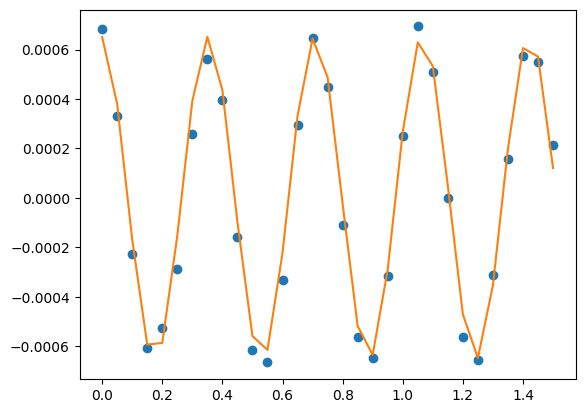

In [2]:
amp = "/2025-02-17/2025-02-17T100135_bc4663d0-c1_ge_pi_amp"
dd_amp = datadict_from_hdf5(header + amp +"/data")


s11 = dd_amp['s11']['values']
amp = dd_amp['amplitude']['values']

a = Analysis(s11, amp)
res = a.fit_1d(kind="rabi")
print(res.fit_report())
plt.plot(amp, a.pca(), "o")
plt.plot(amp, res.best_fit)
# plt.plot(amp, res.init_fit)
plt.show()

In [6]:
from sklearn.decomposition import PCA
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [7]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

In [53]:
amp = "/2025-02-23/2025-02-23T112159_f5a6926c-c1_ge_pi_amp"
dd_amp = datadict_from_hdf5(header + amp +"/data")


Rabi_amp = dd_amp['s11']['values']
imag_amp = Rabi_amp.imag
amp = dd_amp['amplitude']['values']

I_amp = (Rabi_amp.real)
Q_amp = (Rabi_amp.imag)
PCA_amp = PCA_transform(I_amp, Q_amp)

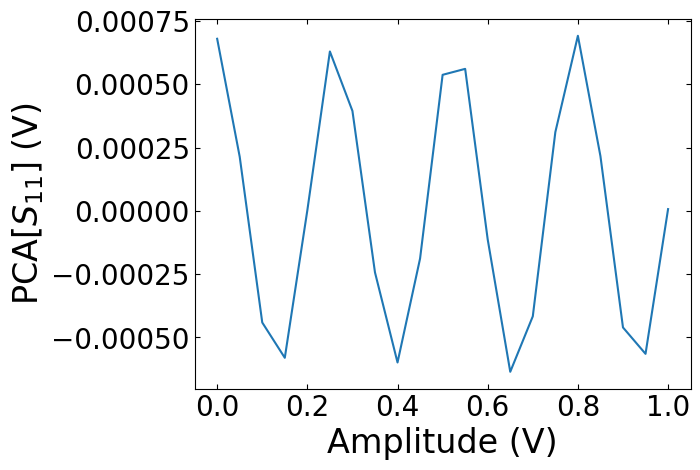

In [54]:
fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Amplitude (V)', size='large')
ax1.set_ylabel('PCA[$S_{11}$] (V)', size='large')
plt.rcParams["font.size"] = 17
plt.plot(amp, PCA_amp[0])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 1)
# ax1.set_ylim(-48, 160)
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
plt.show()

In [55]:
par_ini= {'amp': 0.0005,'phi0':np.pi,'detun':1/0.25,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.inf}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}

model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result = model.fit(data = PCA_amp[0], params = params, delay = amp)
result

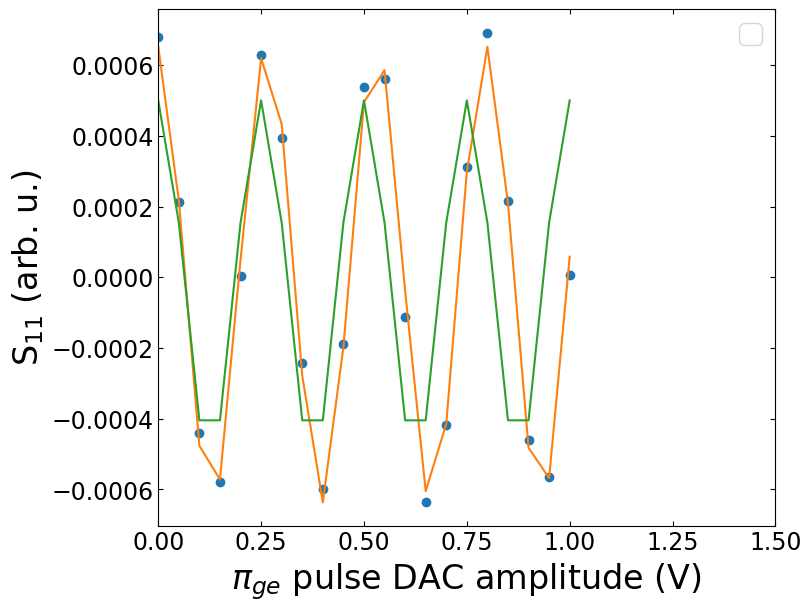

In [56]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(amp, result.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel('$\pi_{ge}$ pulse DAC amplitude (V)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
ax.set_xlim(0, 1.5)
# plt.savefig('ge_rabi.png', bbox_inches='tight')
plt.show()

In [57]:
np.pi/(3.75263328*2*np.pi)*5

0.6661988565000415

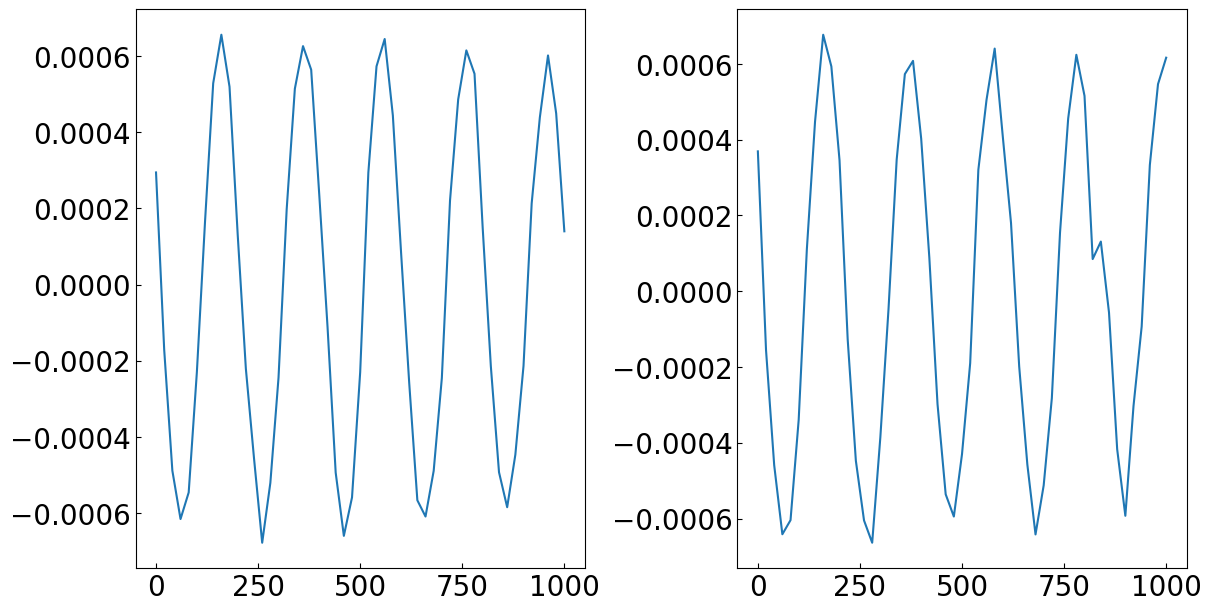

In [48]:
pl ="/2025-02-23/2025-02-23T112016_b8cb6256-c3_ge_T2r1d"
mi =  "/2025-02-23/2025-02-23T112041_c7686a49-c3_ge_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

Rabi_pl = dd_pl['s11']['values']
delay_pl = dd_pl['delay']['values']
Rabi_mi = dd_mi['s11']['values']
delay_mi = dd_mi['delay']['values']

I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)

PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
ax[0].plot(x_pl, y_pl)
ax[1].plot(x_mi, y_mi)
plt.show()

In [49]:
par_ini_pl = {'amp': 0.0003,'phi0':-np.pi/2,'detun':1/220,'const':0.00001}
par_ini_mi = {'amp': 0.0003,'phi0':-np.pi/2,'detun':1/220,'const':0.00001}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':0}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}

model = lmfit.Model(Rabi)

params_pl = model.make_params()
for name in model.param_names:
    params_pl[name].set(value = par_ini_pl[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result_pl = model.fit(data = y_pl, params = params_pl, delay = x_pl)
result_pl

In [50]:
params_mi = model.make_params()
for name in model.param_names:
    params_mi[name].set(value = par_ini_mi[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result_mi = model.fit(data = y_mi, params = params_mi, delay = x_mi)
result_mi

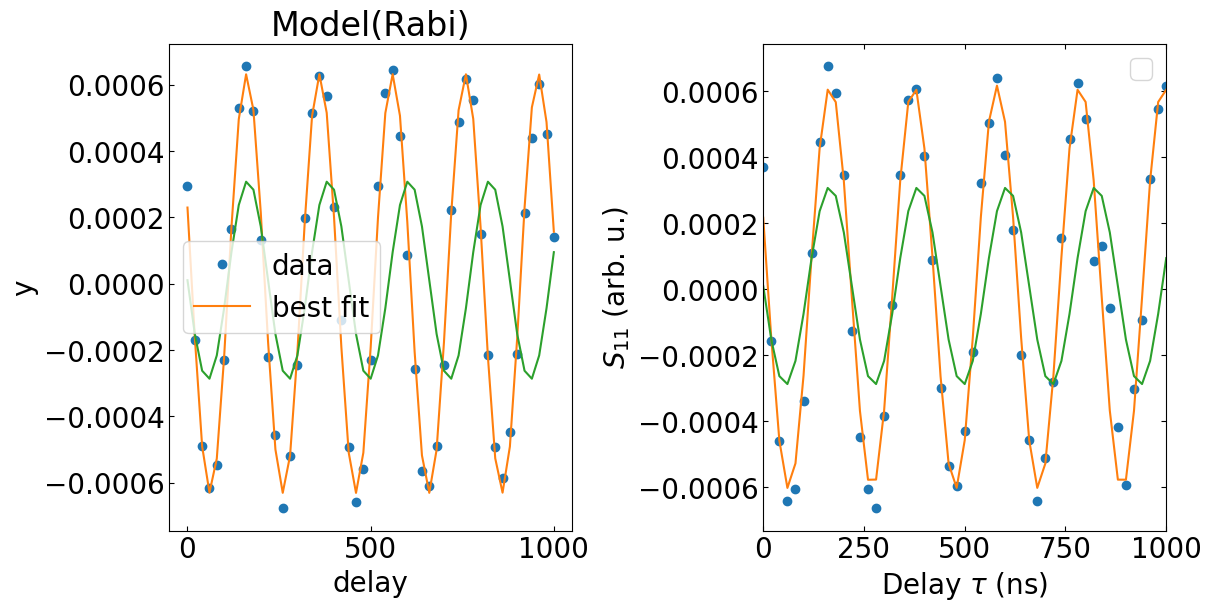

In [51]:
fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax[0])
ax[0].plot(x_pl,result_pl.init_fit)
result_mi.plot_fit(ax = ax[1])
ax[1].plot(x_mi,result_mi.init_fit)

plt.title("")
plt.legend("")
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")
plt.xlim(0, 1000)
# plt.savefig('ef_ramsey_exp.png', bbox_inches='tight')
plt.show()

In [52]:
detun = ((0.005-0.00501934)+ (0.00483819-0.005))/2 #GHz
detun

-9.057499999999986e-05

drag

In [60]:
drag = "/2025-02-23/2025-02-23T112314_22d7a958-c2_ge_pi_drag" # n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2025-02-23/2025-02-23T112403_3fdf8560-c2_ge_pi_drag" # n=13
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2025-02-23/2025-02-23T112501_626acdca-c2_ge_pi_drag" # n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [61]:
Rabi_drag = dd_drag['s11']['values']
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [62]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

In [63]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

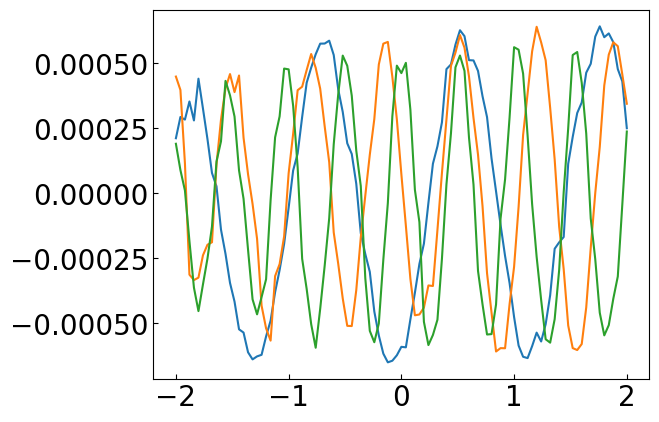

In [64]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [76]:
par_ini= {'amp': 0.00025,'phi0':-np.pi/2,'detun':1/0.5,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.pi}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

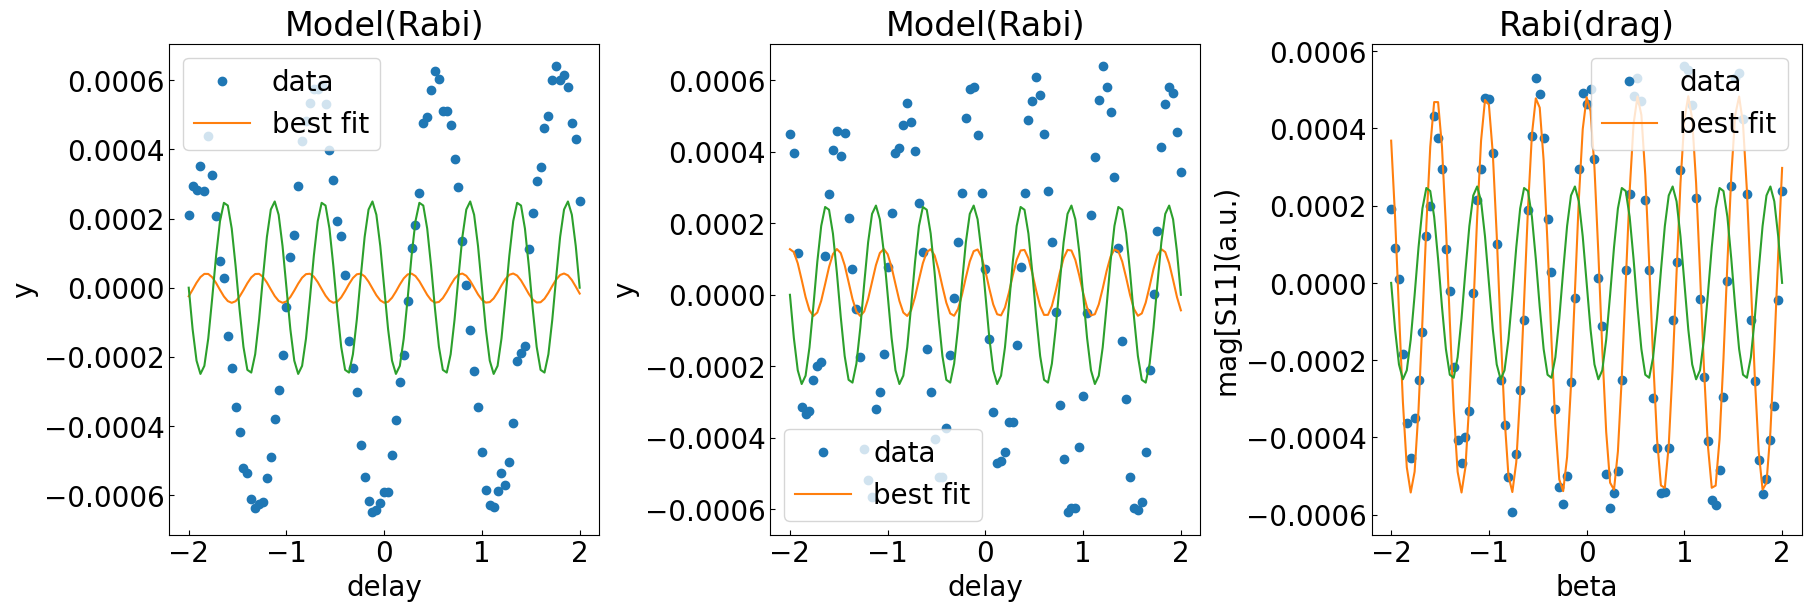

In [77]:
fig, ax = plt.subplots(1,3,figsize=(18,6),constrained_layout=True)
plt.title("Rabi(drag)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax[0])
ax[0].plot(x0,result0.init_fit)
result1.plot_fit(ax = ax[1])
ax[1].plot(x1,result1.init_fit)
result2.plot_fit(ax = ax[2])
ax[2].plot(x2,result2.init_fit)
plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")
plt.show()

In [67]:
result0

In [68]:
res0 = (np.pi-0.38827027)/(2*np.pi*0.81025113)
res0

0.5408259872144517

In [72]:
result1

In [74]:
res1 = (np.pi+1.85852654)/(2*np.pi*1.48739623)
res1

0.5350246757775344

In [78]:
result2

In [79]:
res2 = (np.pi+3.23952372)/(2*np.pi*1.93787900)
res2

0.5240710143932853

In [80]:
beta = (res0 + res1 + res2)/3
beta

0.5333072257950905

half drag

In [81]:
drag = "/2025-02-23/2025-02-23T112836_e2c18da6-c2_ge_pi_half_drag" # n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2025-02-23/2025-02-23T112924_fef39588-c2_ge_pi_half_drag" # n=13
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2025-02-23/2025-02-23T113013_1c2a2db0-c2_ge_pi_half_drag" # n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [82]:
Rabi_drag = dd_drag['s11']['values']
imag_drag = Rabi_drag.imag
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
imag_drag1 = Rabi_drag1.imag
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
imag_drag2 = Rabi_drag2.imag
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [83]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
x = amp
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

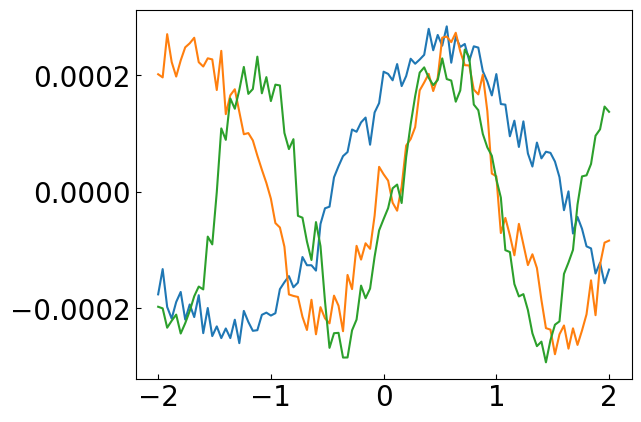

In [84]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [91]:
par_ini= {'amp': 0.0002,'phi0':np.pi/2,'detun':1/3,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.pi}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}
model = lmfit.Model(Rabi)

model = lmfit.Model(Rabi)
params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

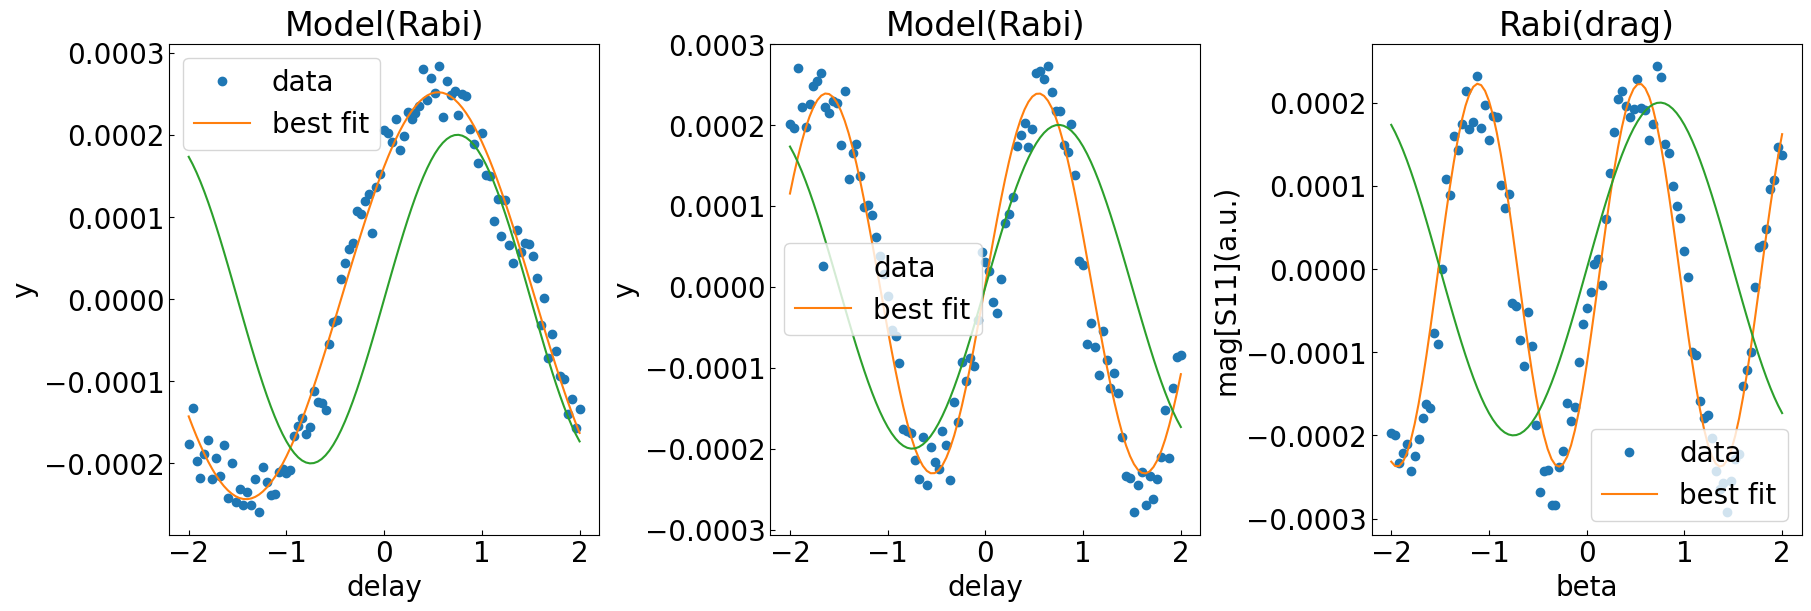

In [92]:
fig, ax = plt.subplots(1,3,figsize=(18,6),constrained_layout=True)
plt.title("Rabi(drag)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax[0])
ax[0].plot(x0,result0.init_fit)
result1.plot_fit(ax = ax[1])
ax[1].plot(x1,result1.init_fit)
result2.plot_fit(ax = ax[2])
ax[2].plot(x2,result2.init_fit)
plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")
plt.show()

In [87]:
result0

In [88]:
res0 = (np.pi -2.25823070)/(2*np.pi*0.25418752)
res0

0.5531011965226658

In [89]:
result1

In [90]:
res1 = (np.pi-1.56832658)/(2*np.pi*0.46059692)
res1

0.5436273269273992

In [93]:
result2

In [94]:
res2 = (np.pi-1.08428261)/(2*np.pi*0.60456655)
res2

0.5415963931678296

In [95]:
beta = (res0 + res1 + res2)/3
beta

0.5461083055392982

T1

In [95]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2025-02-17/2025-02-17T154303_6ff6ebda-c4_ge_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

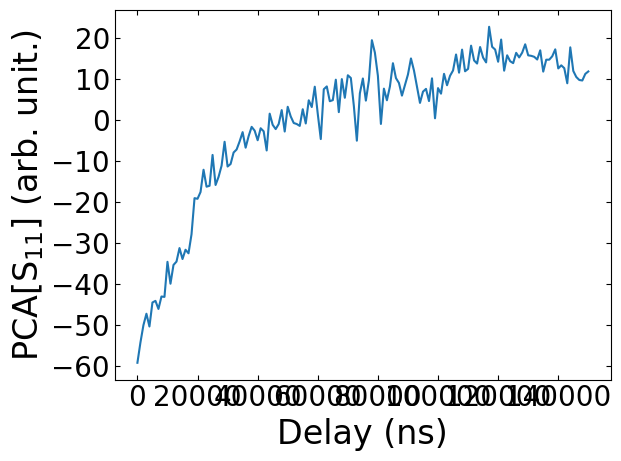

In [96]:
s11_t1 = dd_t1['s11']['values']#[0:180]
delay_t1 = dd_t1['delay']['values']#[0:180]
I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)
PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

fig, (ax1) = plt.subplots(nrows=1)
ax1.set_xlabel('Delay (ns)', size='large')
ax1.set_ylabel('PCA[S$_{11}$] (arb. unit.)', size='large')
plt.rcParams["font.size"] = 10
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)
plt.tick_params(top='on',bottom='on`',left='on',right='on',)

plt.plot(x_t1, y_t1)
plt.show()

In [99]:
par_ini_t1 = {'gamma': 1/40000e-3,'amp':1,'const':-2.4}
par_min_t1 = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t1 = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t1 = {'gamma': True,'amp':True,'const':True}

model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = -y_t1, params = params, delay = x_t1*1e-3)
result_t1

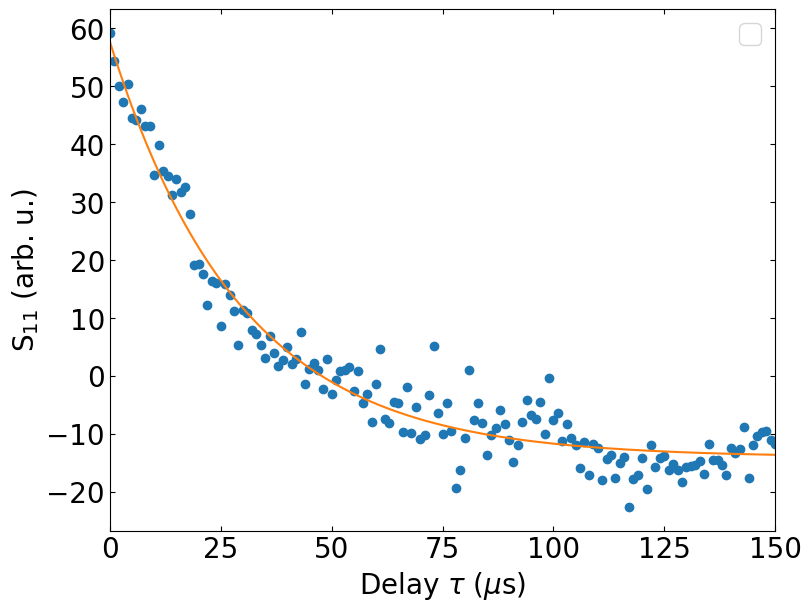

In [100]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
# plt.plot(x_t1,result_t1.init_fit, label='init fit')
# ax.set_ylim(-8, 15)
plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')#, size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)')

plt.xlim(0, 150)
# plt.savefig('ge_T1.png', bbox_inches='tight')
plt.show()

In [101]:
T1 = (1/0.03416369)*1e-9	
T1

2.927084281586679e-08

T2_echo

In [102]:
t2e = "/2025-02-17/2025-02-17T154520_c1bac0ba-c5_ge_T2e"
dd_t2e = datadict_from_hdf5(header + t2e +"/data")

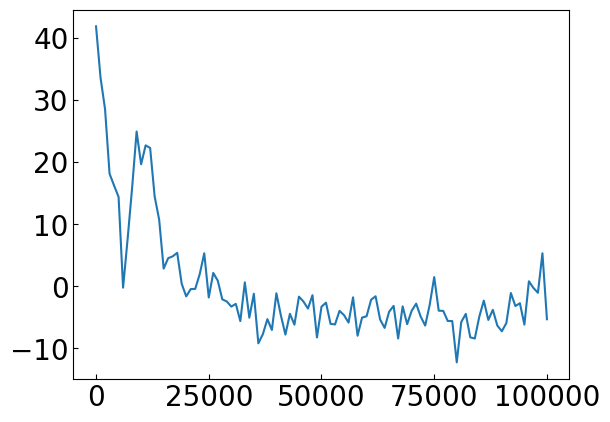

In [103]:
s11_t2e = dd_t2e['s11']['values']
delay_t2e = dd_t2e['delay']['values']
I_t2e = (s11_t2e.real)
Q_t2e = (s11_t2e.imag)
PCA_t2e = PCA_transform(I_t2e, Q_t2e)

y_t2e = PCA_t2e[0]
x_t2e = delay_t2e
plt.plot(x_t2e, y_t2e)
plt.show()

In [105]:
par_ini_t2e = {'gamma': 1/5000e-3,'amp':60,'const':-10}
par_min_t2e = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t2e = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t2e = {'gamma': True,'amp':True,'const':True}

model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t2e[name],
    min = par_min_t2e[name],
    max = par_max_t2e[name],
    vary = par_vary_t2e[name]
    )
result_t2e = model.fit(data = y_t2e, params = params, delay = x_t2e*1e-3)
result_t2e

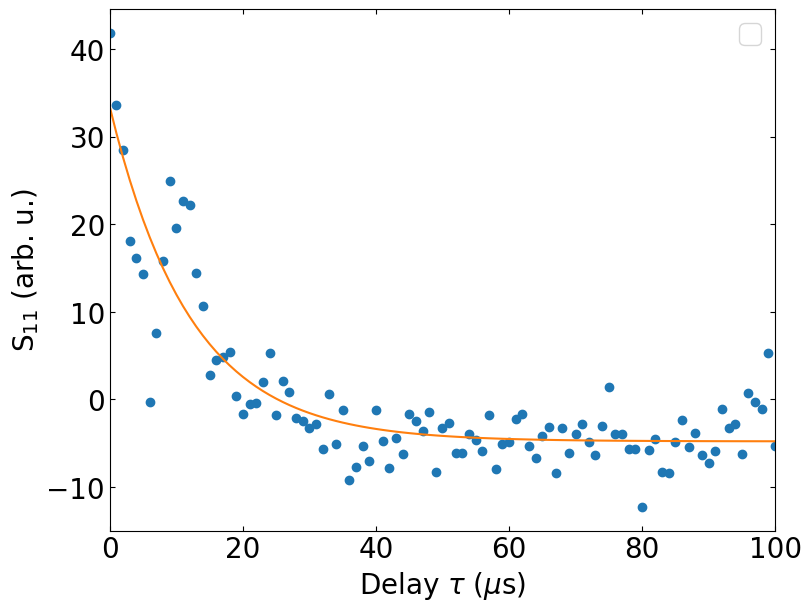

In [106]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2e.plot_fit(ax = ax)
# plt.plot(delay_t2e,result_t2e.init_fit)

# ax.set_ylim(-10, 35)

plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')
ax.set_ylabel('S$_{11}$ (arb. u.)')
plt.xlim(0, 100)
# plt.savefig('ge_T2e.png', bbox_inches='tight')
plt.show()

In [107]:
T2 = (1/0.08229412)*1e-6
T2

1.2151536464573654e-05

T2 star

In [108]:
def t2star(delay, amp, gamma, omega, phi0, const):
    return const + amp * np.exp(- gamma*delay)*np.cos(omega*delay + phi0)

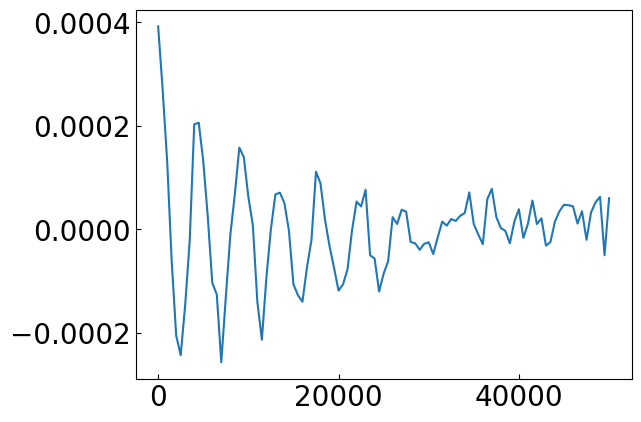

In [138]:
t2 = "/2025-02-17/2025-02-17T155333_e71fb8fc-c3_ge_T2r1d"
dd_t2 = datadict_from_hdf5(header + t2 +"/data")

s11_t2 = dd_t2['s11']['values']
delay_t2 = dd_t2['delay']['values']
I_t2 = (s11_t2.real)
Q_t2 = (s11_t2.imag)
PCA_t2 = PCA_transform(I_t2, Q_t2)

y_t2 = PCA_t2[0]
x_t2 = delay_t2

plt.plot(x_t2, y_t2)
plt.show()

In [139]:
par_ini_t2 = {'amp':0.0003,'gamma': 1/15000e-3,'omega':2*np.pi/7000e-3,'phi0':0,'const':0}
par_min_t2 = {'amp':-np.inf,'gamma': 0,'omega':-2*np.pi,'phi0':-2*np.pi,'const':-np.inf}
par_max_t2 = {'amp':np.inf,'gamma': np.inf,'omega':np.inf,'phi0':2*np.pi,'const':np.inf}
par_vary_t2 = {'amp':True,'gamma': True,'omega':True,'phi0':True,'const':True}

model = lmfit.Model(t2star)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini_t2[name],min = par_min_t2[name],max = par_max_t2[name],vary = par_vary_t2[name])
result_t2 = model.fit(data = y_t2, params = params, delay = x_t2*1e-3)
result_t2

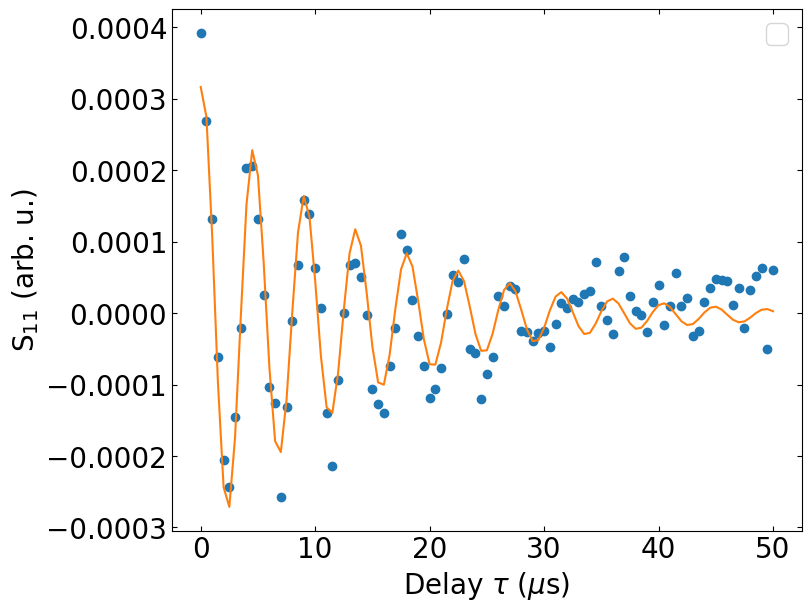

In [141]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t2.plot_fit(ax = ax)
# plt.plot(delay_t2*1e-3,result_t2.init_fit)
# ax.set_ylim(-10, 35)
plt.title("")
plt.legend("")
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')
ax.set_ylabel('S$_{11}$ (arb. u.)')
# ax.set_xlim(0, 20)
# plt.savefig('ge_T2star.png', bbox_inches='tight')
plt.show()

In [142]:
T2_star = (1/0.07355082)*1e-6
T2_star

1.3596041485329462e-05